# Credit Card Fraud Detection

This notebook aims to build a model that can look at a credit card transaction and predict whether it's genuine or fraudulent.

**Dataset:** The Credit Card Fraud Detection dataset is used, which is available on Kaggle from the Machine Learning Group at Université Libre de Bruxelles (ULB). It contains 284,807 transactions made by European cardholders over two days in September 2013, with 492 of them being fraudulent (that's about 0.17%). The features `V1`-`V28` are anonymized components from a PCA transformation; `Time` and `Amount` are the only original features.

The following steps are performed:
1.  Loading the data.
2.  Exploring the data.
3.  Preparing the data for the model.
4.  Training a model.
5.  Evaluating model performance.
6.  Predicting on a new transaction.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib

np.random.seed(42)

## Step 1: Load the Data

The `creditcard.csv` file should be in the correct folder for this notebook. It can be downloaded from [Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) (it requires a free Kaggle account) and placed in the `/content/sample_data/` directory before running this cell.

In [19]:
df = pd.read_csv("/content/sample_data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


First, check the current working directory and available files to confirm the file path.

In [20]:
import os

# Print the current working directory
print("Current working directory:", os.getcwd())

# List files in the current directory
print("Files in current directory:", os.listdir('.'))

# List files in the /content directory (common for uploads in Colab)
print("Files in /content directory:", os.listdir('/content'))

Current working directory: /content
Files in current directory: ['.config', 'sample_data']
Files in /content directory: ['.config', 'sample_data']


## Step 2: Explore the Data

In [21]:
print("Total transactions:", len(df))
print(df["Class"].value_counts())
print("Percent fraud: {:.3f}%".format(100 * df["Class"].mean()))

Total transactions: 284807
Class
0    284315
1       492
Name: count, dtype: int64
Percent fraud: 0.173%


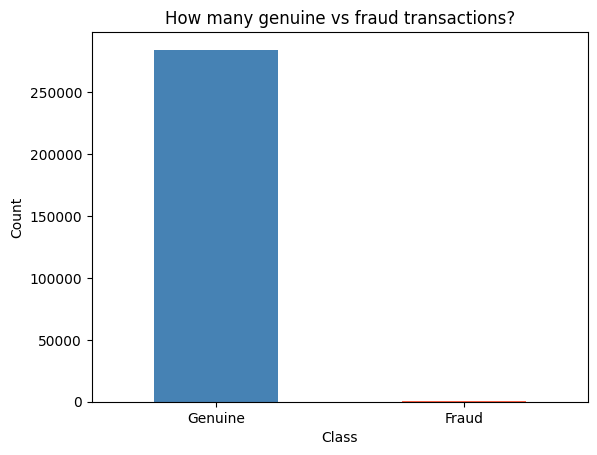

In [22]:
df["Class"].value_counts().plot(kind="bar", color=["steelblue", "tomato"])
plt.xticks([0, 1], ["Genuine", "Fraud"], rotation=0)
plt.title("How many genuine vs fraud transactions?")
plt.ylabel("Count")
plt.show()

**Observation:** Fraud is a *very* small fraction of the total transactions. This is important for subsequent steps — if predictions were always "genuine", the model would still be right almost all the time, but it would not catch any fraud. Due to this imbalance, models are evaluated using precision and recall, not just accuracy.

## Step 3: Prepare the Data

In [23]:
scaler = StandardScaler()
df_cleaned = df.dropna(subset=['Class']) # Drop rows where 'Class' is NaN
df_cleaned[["Time", "Amount"]] = scaler.fit_transform(df_cleaned[["Time", "Amount"]])

X = df_cleaned.drop(columns=["Class"])
y = df_cleaned["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Training rows:", len(X_train), "| Testing rows:", len(X_test))

Training rows: 227845 | Testing rows: 56962


## Step 4: Train the Model

Since fraud is rare, models need to pay **extra attention to the fraud class**. This is achieved by using `class_weight="balanced"`, a built-in scikit-learn setting that helps models avoid ignoring the rare class.

Two models are trained and compared:
-   **Logistic Regression** — serves as a simple, interpretable baseline.
-   **Decision Tree** — makes predictions by splitting data into a series of yes/no questions.

In [24]:
log_reg = LogisticRegression(class_weight="balanced", max_iter=1000)
log_reg.fit(X_train, y_train)

tree = DecisionTreeClassifier(class_weight="balanced", max_depth=6, random_state=42)
tree.fit(X_train, y_train)

models = {"Logistic Regression": log_reg, "Decision Tree": tree}
print("Models trained.")

Models trained.


## Step 5: Evaluate Model Performance

**Accuracy** is considered, but also **precision** (which indicates how many of the flagged fraud transactions were actually fraudulent) and **recall** (which indicates how much of the actual fraud was caught). Accuracy alone can be misleading with imbalanced data, making precision and recall more informative.

In [25]:
for name, model in models.items():
    preds = model.predict(X_test)
    print(f"--- {name} ---")
    print("Accuracy: ", round(accuracy_score(y_test, preds), 4))
    print("Precision:", round(precision_score(y_test, preds), 4))
    print("Recall:   ", round(recall_score(y_test, preds), 4))
    print("F1 score: ", round(f1_score(y_test, preds), 4))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, preds))
    print()

--- Logistic Regression ---
Accuracy:  0.9755
Precision: 0.0609
Recall:    0.9184
F1 score:  0.1141
Confusion matrix:
[[55475  1389]
 [    8    90]]

--- Decision Tree ---
Accuracy:  0.9763
Precision: 0.0585
Recall:    0.8469
F1 score:  0.1094
Confusion matrix:
[[55527  1337]
 [   15    83]]



**Reading the confusion matrix:**
```
[[True Genuine    False Fraud Alarms]
 [Missed Fraud     Caught Fraud     ]]
```
There is a trade-off: catching more fraud (higher recall) usually results in more false alarms (lower precision), and vice versa. The importance of each depends on specific business needs.

## Step 6: Try It on a New Transaction

In [26]:
sample = X_test.sample(1, random_state=5)
true_label = y_test.loc[sample.index[0]]

prediction = tree.predict(sample)[0]
probability = tree.predict_proba(sample)[0][1]

print("Model prediction:", "FRAUD" if prediction == 1 else "Genuine")
print("Fraud probability:", round(probability, 3))
print("Actual answer:    ", "FRAUD" if true_label == 1 else "Genuine")

Model prediction: Genuine
Fraud probability: 0.0
Actual answer:     Genuine


## Step 7: Save the Model

The trained model is saved for later reuse, for example, in an accompanying application, without needing retraining.

In [27]:
best_model = tree  # change to log_reg here if you prefer that one
joblib.dump(best_model, "fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")
X_test.assign(Class=y_test).to_csv("test_sample.csv", index=False)
print("Saved fraud_model.pkl, scaler.pkl, test_sample.csv")

Saved fraud_model.pkl, scaler.pkl, test_sample.csv


## Conclusion

-   Real transaction data was loaded, confirming that fraud is very rare (about 0.17% of transactions).
-   Data imbalance was handled by using `class_weight="balanced"`, which ensures the model does not ignore the rare fraud class.
-   A Logistic Regression model was compared with a Decision Tree.
-   Models were evaluated using precision, recall, and F1-score rather than just accuracy, as accuracy can be misleading with imbalanced data.
-   Finally, the trained model was saved for reuse in an accompanying Streamlit app.

